# Projet Data Mining – Classification : Telco Customer Churn

## 1. Introduction

### Dataset utilisé
Le dataset choisi est **Telco Customer Churn**.

### Objectif
Prédire si un client va quitter l’entreprise (Churn) ou rester.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

## 2. Chargement des données

In [3]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Analyse des données

In [4]:
print(df.shape)
df.info()
df.describe()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 4. Valeurs manquantes

In [5]:
print(df.isnull().sum())

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


## 5. Valeurs aberrantes

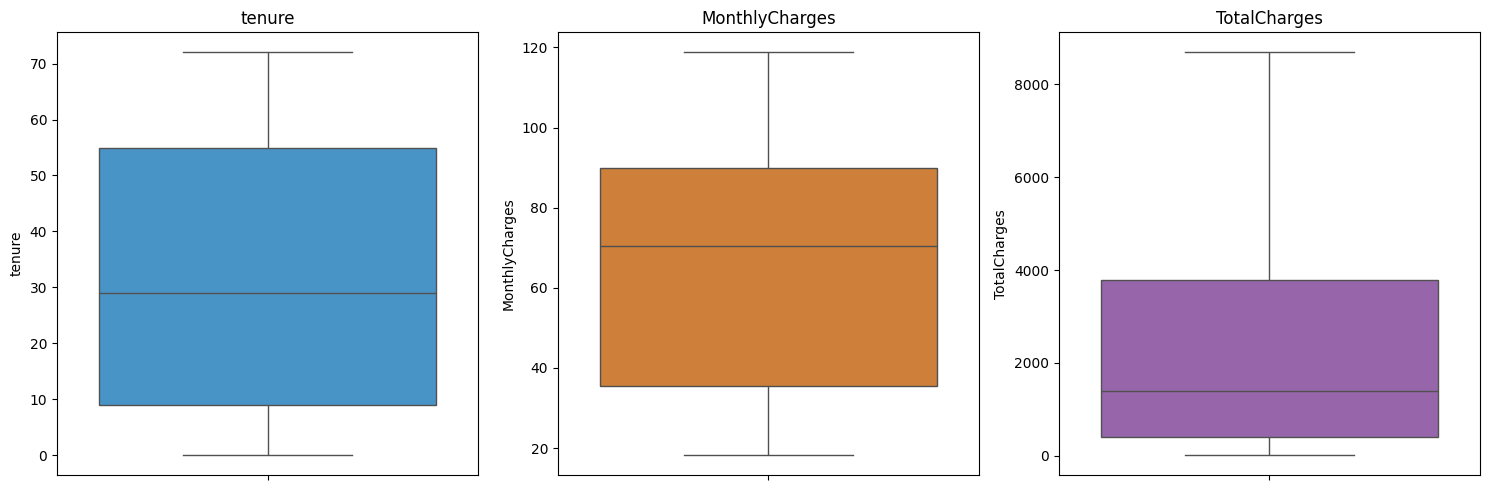

In [6]:
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15,5))
colors = ['#3498db', '#e67e22', '#9b59b6']
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(1,3,i)
    sns.boxplot(y=df[col], color=colors[i-1])
    plt.title(col)

plt.tight_layout()
plt.show()

## 6. Distribution des données

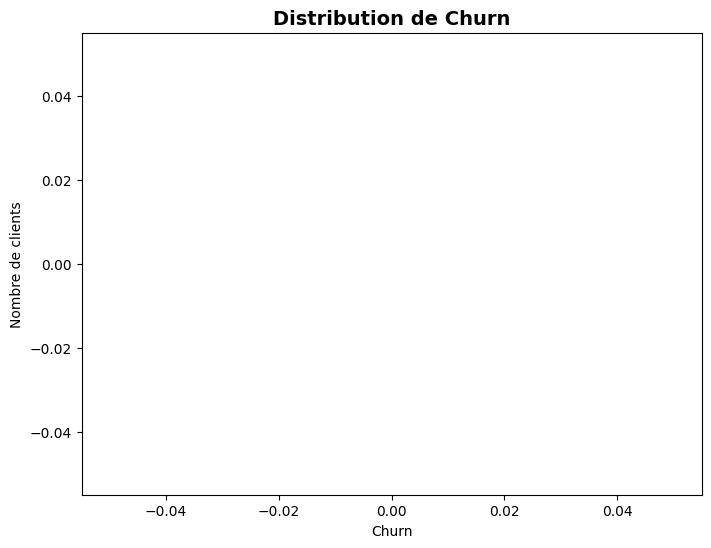

In [7]:
plt.figure(figsize=(8, 6))
churn_counts = df['Churn'].map({0:'No', 1:'Yes'}).value_counts()
colors = ['#2ecc71', '#e74c3c']
plt.bar(
    churn_counts.index,
    churn_counts.values,
    color=colors,
    edgecolor='black'
)
plt.title('Distribution de Churn', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Nombre de clients')

plt.show()

## 7. Prétraitement

In [8]:
df.drop('customerID', axis=1, inplace=True)

le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

X = df.drop('Churn', axis=1)
y = df['Churn']

X = pd.get_dummies(X, drop_first=True)

imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42,stratify=y)

## 8. Modèle KNN

In [9]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision :", precision_score(y_test, y_pred_knn))
print("Recall :", recall_score(y_test, y_pred_knn))
print("F1-score :", f1_score(y_test, y_pred_knn))

print(classification_report(y_test, y_pred_knn))

Accuracy : 0.7466288147622427
Precision : 0.5238095238095238
Recall : 0.5
F1-score : 0.5116279069767442
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1035
           1       0.52      0.50      0.51       374

    accuracy                           0.75      1409
   macro avg       0.67      0.67      0.67      1409
weighted avg       0.74      0.75      0.74      1409



 Confusion Matrix KNN 


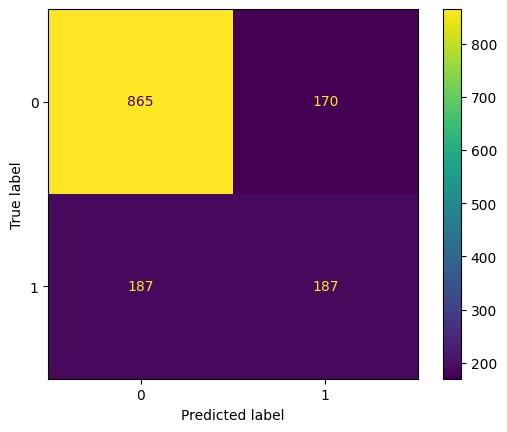

 Precision 
0.6730264349085642


In [10]:
print(" Confusion Matrix KNN ")
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
print(" Precision ")
print(precision_score(y_test, y_pred_knn, average='macro'))

## 9. Arbre de Décision

In [11]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision :", precision_score(y_test, y_pred_dt))
print("Recall :", recall_score(y_test, y_pred_dt))
print("F1-score :", f1_score(y_test, y_pred_dt))

print(classification_report(y_test, y_pred_dt))

Accuracy : 0.7423704755145494
Precision : 0.5153203342618384
Recall : 0.4946524064171123
F1-score : 0.504774897680764
              precision    recall  f1-score   support

           0       0.82      0.83      0.83      1035
           1       0.52      0.49      0.50       374

    accuracy                           0.74      1409
   macro avg       0.67      0.66      0.67      1409
weighted avg       0.74      0.74      0.74      1409



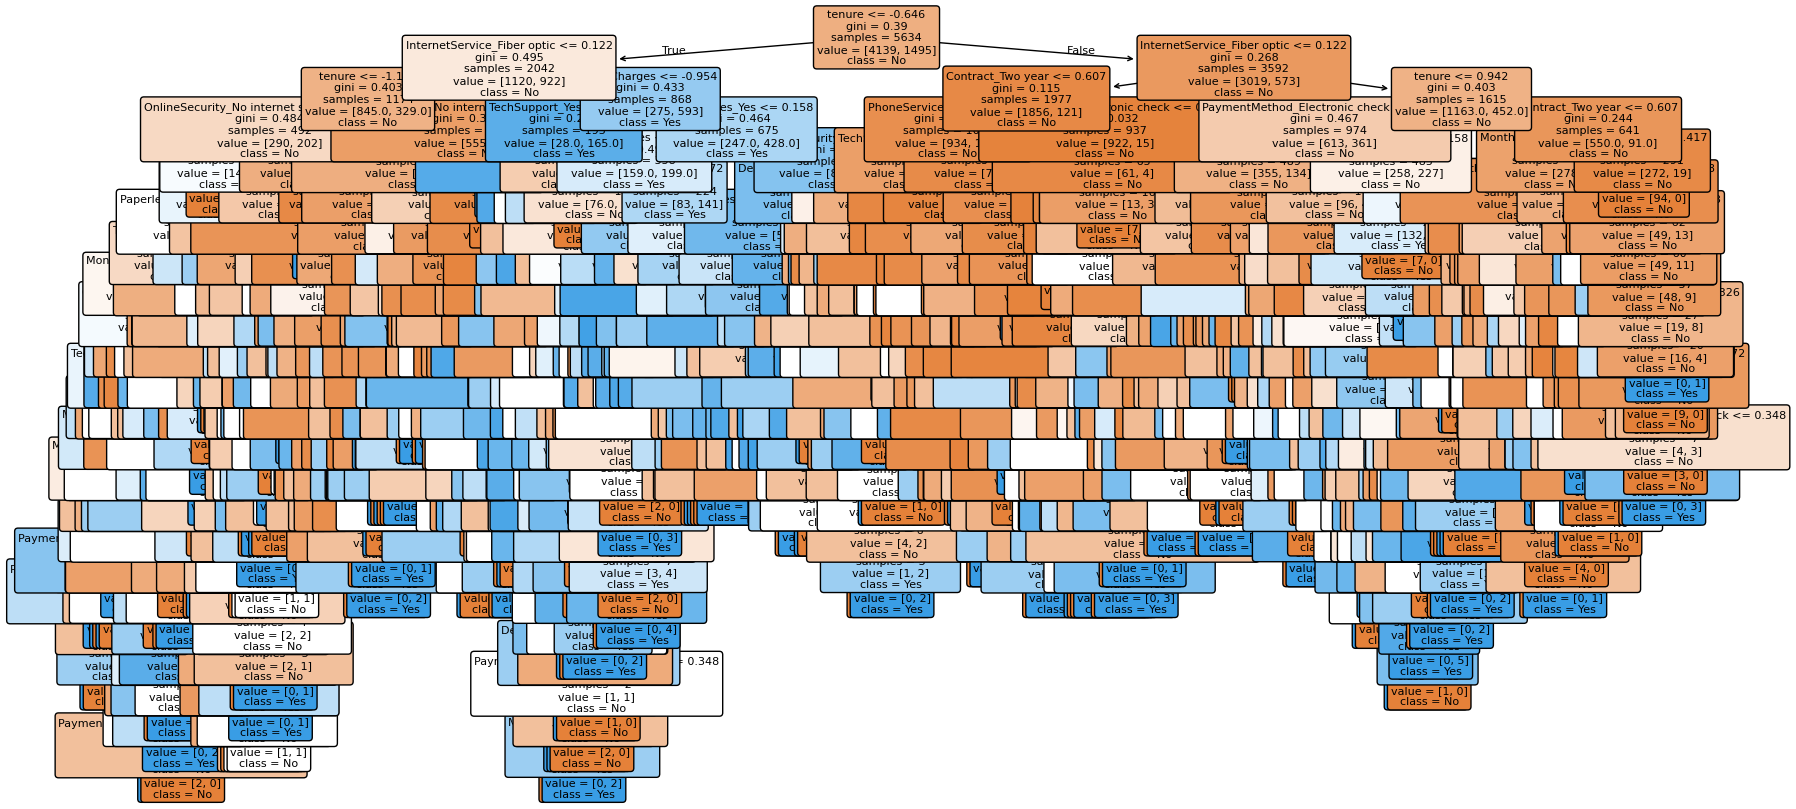

In [12]:
#affichage de l'arbre de decision
plt.figure(figsize=(20,10))
plot_tree(dt,feature_names=X.columns,class_names=['No', 'Yes'],filled=True,rounded=True,fontsize=8)
plt.show()

 Confusion Matrix Decision Tree 


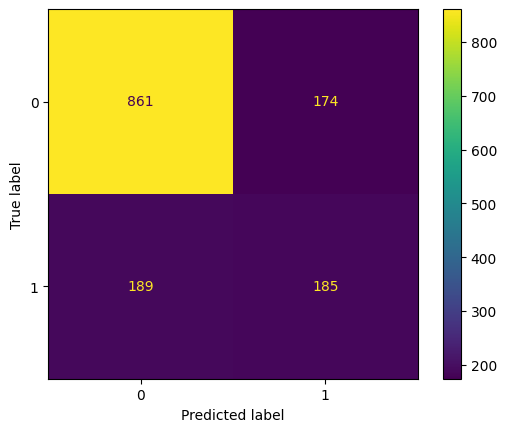

 Precision 
0.6676601671309192


In [13]:
print(" Confusion Matrix Decision Tree ")
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
print(" Precision ")
print(precision_score(y_test, y_pred_dt, average='macro'))

## 10. Random Forest

In [14]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision :", precision_score(y_test, y_pred_rf))
print("Recall :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy : 0.7877927608232789
Precision : 0.6262626262626263
Recall : 0.49732620320855614
F1-score : 0.5543964232488823
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



 Confusion Matrix Random Forest 


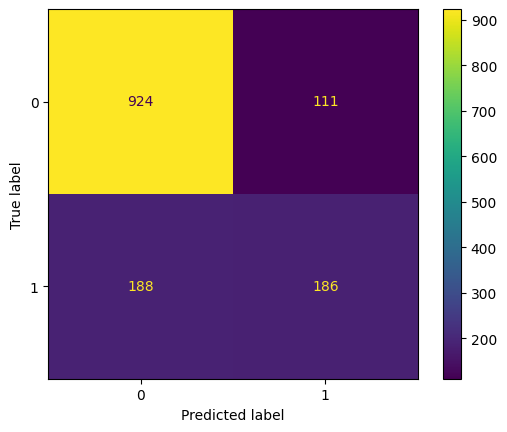

 Precision 
0.7285989390305938


In [15]:
print(" Confusion Matrix Random Forest ")
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
print(" Precision ")
print(precision_score(y_test, y_pred_rf, average='macro'))

## 11. Réseau de neurones MLP

In [16]:
mlp = MLPClassifier(hidden_layer_sizes=(100,50),max_iter=500,random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred_mlp))
print("Precision :", precision_score(y_test, y_pred_mlp))
print("Recall :", recall_score(y_test, y_pred_mlp))
print("F1-score :", f1_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))

Accuracy : 0.7530163236337828
Precision : 0.5353260869565217
Recall : 0.5267379679144385
F1-score : 0.5309973045822103
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1035
           1       0.54      0.53      0.53       374

    accuracy                           0.75      1409
   macro avg       0.68      0.68      0.68      1409
weighted avg       0.75      0.75      0.75      1409



Confusion Matrix MLP 


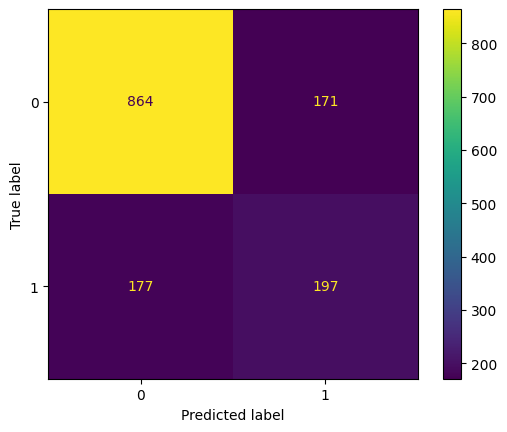

Precision 
0.6826486342563589


In [17]:
print("Confusion Matrix MLP ")
cm = confusion_matrix(y_test, y_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()
print("Precision ")
print(precision_score(y_test, y_pred_mlp, average='macro'))

## 12. Comparaison des modèles

In [18]:
results = pd.DataFrame({
    'Modèle': ['KNN', 'Decision Tree', 'Random Forest', 'MLP'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_mlp)
    ],
    'Precision': [
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_mlp)
    ],
    'Recall': [
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_mlp)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_mlp)
    ]
})

results

,Modèle,Accuracy,Precision,Recall,F1-score
0,KNN,0.746629,0.523810,0.500000,0.511628
1,Decision Tree,0.742370,0.515320,0.494652,0.504775
2,Random Forest,0.787793,0.626263,0.497326,0.554396
3,MLP,0.753016,0.535326,0.526738,0.530997


# Conclusion

Le modèle Random Forest donne généralement les meilleures performances.

Le prétraitement des données et la standardisation ont amélioré les résultats des modèles.
